当前使用设备: cuda
开始训练...

Epoch  1 | Batch  100 | Loss: 1.785 | Acc: 33.30%
Epoch  1 | Batch  200 | Loss: 1.459 | Acc: 39.95%
Epoch  1 | Batch  300 | Loss: 1.308 | Acc: 44.25%

测试集结果: 平均Loss: 1.066 | 总准确率: 61.94%
----------------------------------------
plane 准确率: 59.80%
car   准确率: 86.20%
bird  准确率: 46.70%
cat   准确率: 44.50%
deer  准确率: 47.70%
dog   准确率: 53.20%
frog  准确率: 79.80%
horse 准确率: 47.50%
ship  准确率: 80.50%
truck 准确率: 73.50%
----------------------------------------

Epoch  2 | Batch  100 | Loss: 1.119 | Acc: 60.05%
Epoch  2 | Batch  200 | Loss: 1.061 | Acc: 60.98%
Epoch  2 | Batch  300 | Loss: 1.007 | Acc: 62.05%

测试集结果: 平均Loss: 0.974 | 总准确率: 65.34%
----------------------------------------
plane 准确率: 61.90%
car   准确率: 80.50%
bird  准确率: 44.40%
cat   准确率: 34.40%
deer  准确率: 45.70%
dog   准确率: 68.50%
frog  准确率: 92.80%
horse 准确率: 57.90%
ship  准确率: 78.20%
truck 准确率: 89.10%
----------------------------------------

Epoch  3 | Batch  100 | Loss: 0.923 | Acc: 67.45%
Epoch  3 | Batch  200 | Loss

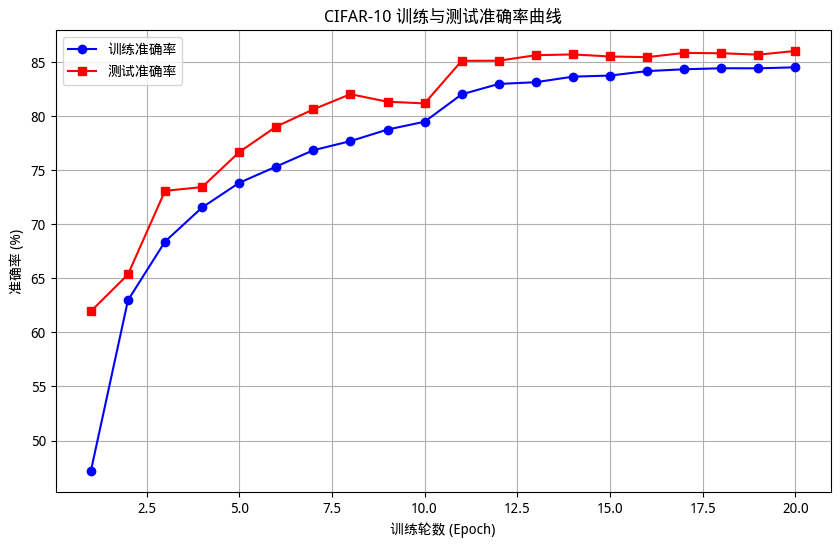

模型已保存为: cifar10_cnn_model.pth
准确率曲线已保存为: accuracy_curve.png


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import time

# ===================== 配置参数 =====================
BATCH_SIZE_TRAIN = 128
BATCH_SIZE_TEST = 100
NUM_EPOCHS = 20
LEARNING_RATE = 0.001
WEIGHT_DECAY = 1e-4
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"当前使用设备: {DEVICE}")

# 设置随机种子保证结果可复现
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

# ===================== 1. 数据预处理与加载 =====================
# 训练集数据增强（提高模型泛化能力）
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),    # 随机裁剪
    transforms.RandomHorizontalFlip(),       # 随机水平翻转
    transforms.ToTensor(),
    # 使用CIFAR-10数据集的官方均值和标准差进行归一化
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])

# 测试集只做归一化
transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])

# 自动下载并加载数据集
trainset = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=False, transform=transform_train)  
trainloader = torch.utils.data.DataLoader(
    trainset, batch_size=BATCH_SIZE_TRAIN, shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=False, transform=transform_test) 
testloader = torch.utils.data.DataLoader(
    testset, batch_size=BATCH_SIZE_TEST, shuffle=False, num_workers=2)

# 10个类别名称
classes = ('plane', 'car', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck')

# ===================== 2. 定义CNN模型 =====================
class CIFAR10CNN(nn.Module):
    def __init__(self):
        super(CIFAR10CNN, self).__init__()
        # 特征提取部分（卷积+池化+批归一化+Dropout）
        self.conv_layers = nn.Sequential(
            # 第一层：3通道输入 -> 32通道输出
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),  # 32x32 -> 16x16
            nn.Dropout(0.25),

            # 第二层：32通道 -> 64通道
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),  # 16x16 -> 8x8
            nn.Dropout(0.25),

            # 第三层：64通道 -> 128通道
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),  # 8x8 -> 4x4
            nn.Dropout(0.25)
        )

        # 分类器部分（全连接层）
        self.fc_layers = nn.Sequential(
            nn.Linear(128 * 4 * 4, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(512, 10)
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = x.view(x.size(0), -1)  # 展平特征图
        x = self.fc_layers(x)
        return x

# ===================== 3. 训练函数 =====================
def train_epoch(model, trainloader, criterion, optimizer, epoch):
    model.train()  # 设置为训练模式
    running_loss = 0.0
    correct = 0
    total = 0

    for batch_idx, (inputs, labels) in enumerate(trainloader):
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)

        # 前向传播
        outputs = model(inputs)
        loss = criterion(outputs, labels)

        # 反向传播与优化
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # 统计指标
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

        # 每100个batch打印一次进度
        if batch_idx % 100 == 99:
            print(f'Epoch {epoch+1:2d} | Batch {batch_idx+1:4d} | '
                  f'Loss: {running_loss/100:.3f} | Acc: {100.*correct/total:.2f}%')
            running_loss = 0.0

    train_acc = 100. * correct / total
    return train_acc

# ===================== 4. 测试函数 =====================
def test(model, testloader, criterion):
    model.eval()  # 设置为评估模式
    test_loss = 0.0
    correct = 0
    total = 0
    class_correct = [0.0] * 10
    class_total = [0.0] * 10

    with torch.no_grad():  # 测试时不计算梯度
        for inputs, labels in testloader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            test_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

            # 统计每个类别的准确率
            c = predicted.eq(labels).squeeze()
            for i in range(labels.size(0)):
                label = labels[i]
                class_correct[label] += c[i].item()
                class_total[label] += 1

    test_acc = 100. * correct / total
    test_loss /= len(testloader)

    print(f'\n测试集结果: 平均Loss: {test_loss:.3f} | 总准确率: {test_acc:.2f}%')
    print('-' * 40)
    for i in range(10):
        print(f'{classes[i]:5s} 准确率: {100 * class_correct[i] / class_total[i]:.2f}%')
    print('-' * 40 + '\n')

    return test_acc, class_correct, class_total

# ===================== 5. 主程序 =====================
if __name__ == '__main__':
    # 初始化模型、损失函数和优化器
    model = CIFAR10CNN().to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    # 学习率调度器：每10轮学习率乘以0.1
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)

    # 记录训练过程
    train_acc_history = []
    test_acc_history = []
    start_time = time.time()

    # 开始训练
    print("开始训练...\n")
    for epoch in range(NUM_EPOCHS):
        train_acc = train_epoch(model, trainloader, criterion, optimizer, epoch)
        test_acc, _, _ = test(model, testloader, criterion)

        train_acc_history.append(train_acc)
        test_acc_history.append(test_acc)

        scheduler.step()

    # 训练结束
    end_time = time.time()
    total_time = end_time - start_time
    print(f'训练完成! 总耗时: {total_time:.2f} 秒')
    print(f'最高测试准确率: {max(test_acc_history):.2f}%')

    # 绘制并保存准确率曲线
    plt.rcParams["font.sans-serif"] = [
    "SimHei",                # Windows 黑体
    "Microsoft YaHei",       # Windows 微软雅黑
    "PingFang SC",           # Mac 苹方
    "Hiragino Sans GB",      # Mac 冬青黑体
    "WenQuanYi Micro Hei",   # Linux 文泉驿微米黑
    "Heiti TC",              # 通用黑体
    "DejaVu Sans"  ]
    plt.rcParams["axes.unicode_minus"] = False
    
    plt.figure(figsize=(10, 6))
    plt.plot(range(1, NUM_EPOCHS+1), train_acc_history, 'b-o', label='训练准确率')
    plt.plot(range(1, NUM_EPOCHS+1), test_acc_history, 'r-s', label='测试准确率')
    plt.title('CIFAR-10 训练与测试准确率曲线')
    plt.xlabel('训练轮数 (Epoch)')
    plt.ylabel('准确率 (%)')
    plt.legend()
    plt.grid(True)
    plt.savefig('accuracy_curve.png', dpi=300, bbox_inches='tight')
    plt.show()

    # 保存训练好的模型
    torch.save(model.state_dict(), 'cifar10_cnn_model.pth')
    print('模型已保存为: cifar10_cnn_model.pth')
    print('准确率曲线已保存为: accuracy_curve.png')

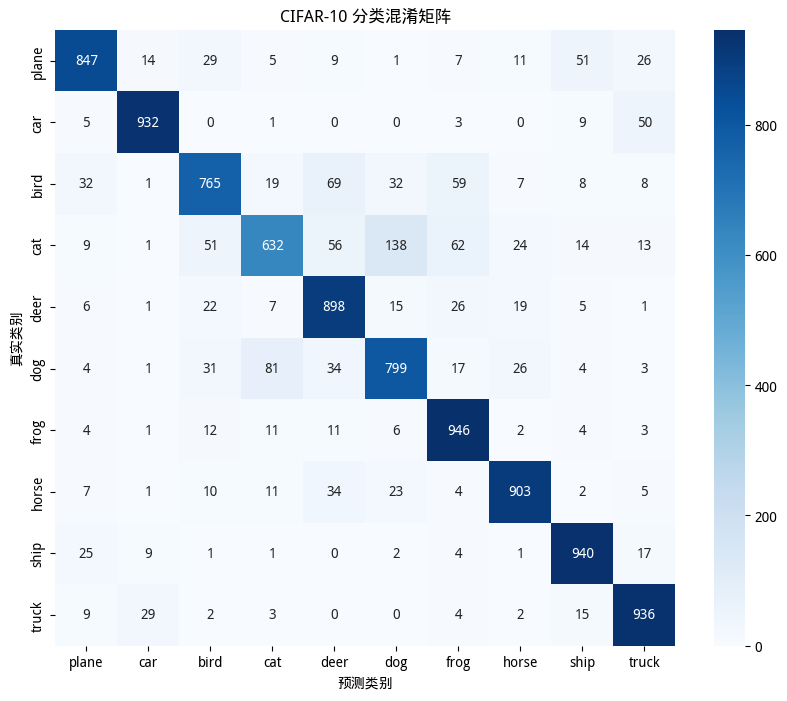

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.9802322e-08..0.9647059].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.9802322e-08..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.9802322e-08..0.9411765].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.9802322e-08..0.87058824].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.9802322e-08..0.6313726].


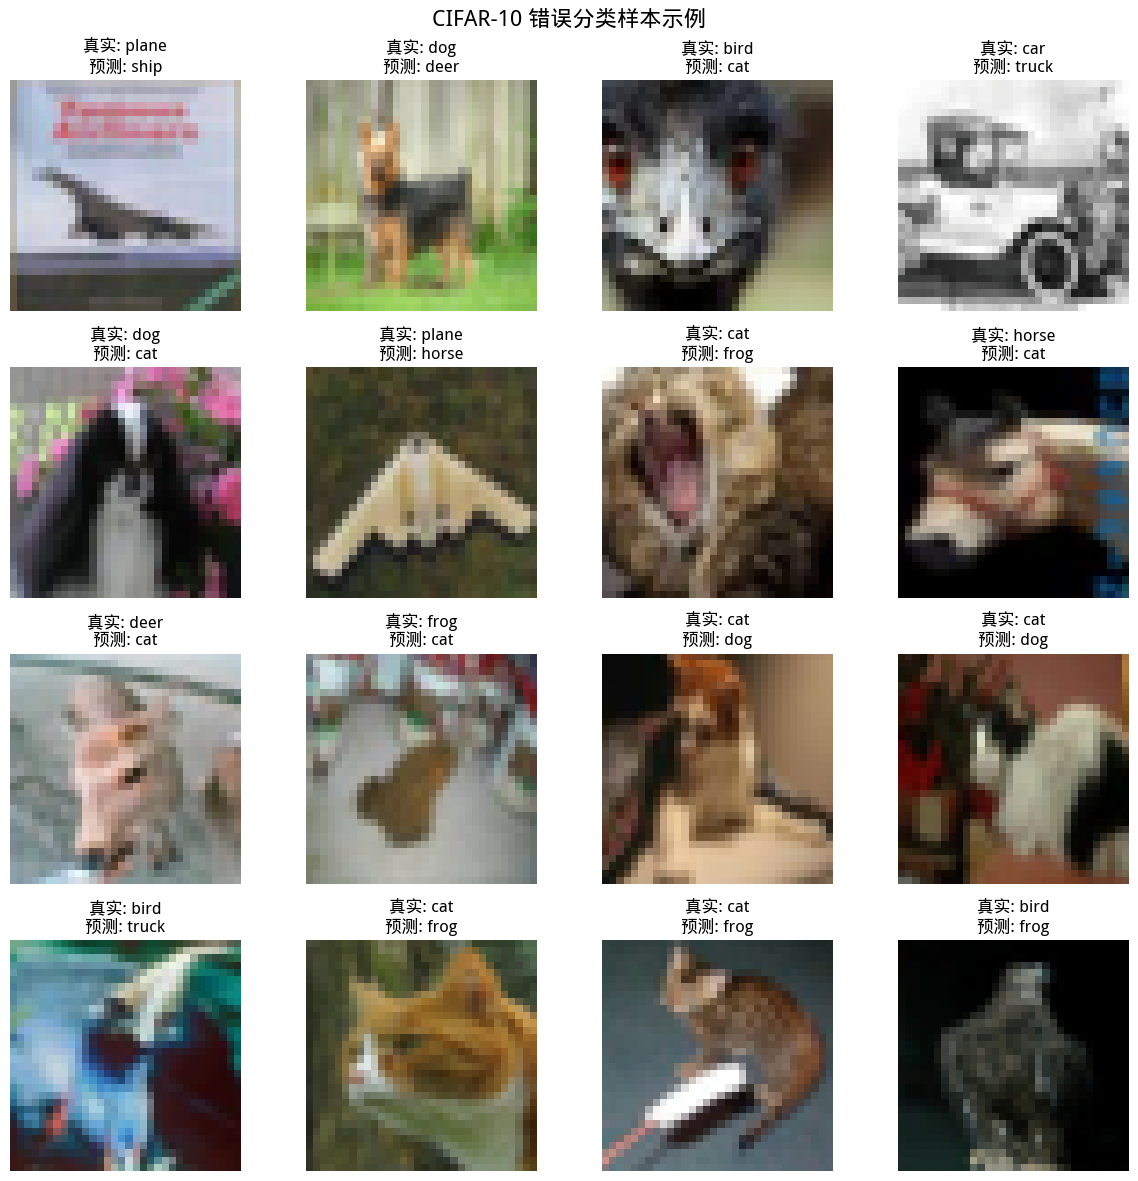

模型已保存为: cifar10_cnn_model.pth
准确率曲线已保存为: accuracy_curve.png
混淆矩阵已保存为: confusion_matrix.png
错误分类样本已保存为: misclassified_samples.png


In [3]:
    # 绘制并保存准确率曲线
    plt.rcParams["font.sans-serif"] = [
    "SimHei",                # Windows 黑体
    "Microsoft YaHei",       # Windows 微软雅黑
    "PingFang SC",           # Mac 苹方
    "Hiragino Sans GB",      # Mac 冬青黑体
    "WenQuanYi Micro Hei",   # Linux 文泉驿微米黑
    "Heiti TC",              # 通用黑体
    "DejaVu Sans"  ]
    plt.rcParams["axes.unicode_minus"] = False
    
    # ===================== 新增：绘制混淆矩阵 =====================
    from sklearn.metrics import confusion_matrix
    import seaborn as sns
    import numpy as np

    # 获取所有测试样本的预测结果
    all_preds = []
    all_labels = []
    model.eval()
    with torch.no_grad():
        for inputs, labels in testloader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            outputs = model(inputs)
            _, predicted = outputs.max(1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # 计算混淆矩阵
    cm = confusion_matrix(all_labels, all_preds)
    
    # 绘制混淆矩阵
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=classes, yticklabels=classes)
    plt.title('CIFAR-10 分类混淆矩阵')
    plt.xlabel('预测类别')
    plt.ylabel('真实类别')
    plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
    plt.show()

    # ===================== 新增：展示错误分类样本 =====================
    # 收集错误分类的样本
    misclassified_images = []
    misclassified_labels = []
    misclassified_preds = []

    model.eval()
    with torch.no_grad():
        for inputs, labels in testloader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            outputs = model(inputs)
            _, predicted = outputs.max(1)
            
            # 找出错误分类的样本
            mask = predicted.ne(labels)
            misclassified_images.extend(inputs[mask].cpu())
            misclassified_labels.extend(labels[mask].cpu())
            misclassified_preds.extend(predicted[mask].cpu())
            
            # 只展示前16个错误样本
            if len(misclassified_images) >= 16:
                break

    # 反归一化函数
    def denormalize(tensor):
        mean = torch.tensor([0.4914, 0.4822, 0.4465]).view(3, 1, 1)
        std = torch.tensor([0.2023, 0.1994, 0.2010]).view(3, 1, 1)
        return tensor * std + mean

    # 绘制错误分类样本
    plt.figure(figsize=(12, 12))
    for i in range(16):
        plt.subplot(4, 4, i+1)
        img = denormalize(misclassified_images[i]).permute(1, 2, 0)
        plt.imshow(img)
        plt.title(f'真实: {classes[misclassified_labels[i]]}\n预测: {classes[misclassified_preds[i]]}')
        plt.axis('off')
    plt.suptitle('CIFAR-10 错误分类样本示例', fontsize=16)
    plt.tight_layout()
    plt.savefig('misclassified_samples.png', dpi=300, bbox_inches='tight')
    plt.show()

    # 保存训练好的模型
    torch.save(model.state_dict(), 'cifar10_cnn_model.pth')
    print('模型已保存为: cifar10_cnn_model.pth')
    print('准确率曲线已保存为: accuracy_curve.png')
    print('混淆矩阵已保存为: confusion_matrix.png')
    print('错误分类样本已保存为: misclassified_samples.png')